# Import libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
med_info = pd.read_csv("C:/Users/Katlego/Downloads/med_info.csv")

In [3]:
med_info.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [4]:
print("Dataset Shape:", med_info.shape)

Dataset Shape: (10000, 15)



**Probability of a female patient with AB+ blood to have a Diabetes medical condition**

In [5]:
female_ab_plus = med_info[(med_info['Gender'] == 'Female') & (med_info['Blood Type'] == 'AB+')]
diabetes_count = len(female_ab_plus[female_ab_plus['Medical Condition'] == 'Diabetes'])

if len(female_ab_plus) > 0:
    prob = (diabetes_count / len(female_ab_plus)) * 100
else:
    prob = 0

print(f"Number of female patients with AB+ blood type: {len(female_ab_plus)}")
print(f"Number with Diabetes: {diabetes_count}")
print(f"Probability: {prob :.1f}%")

Number of female patients with AB+ blood type: 637
Number with Diabetes: 102
Probability: 16.0%


**Dates with least patients admitted**

In [6]:
admissions_by_date = med_info['Date of Admission'].value_counts()
min_admissions = admissions_by_date.min()
least_admission_dates = admissions_by_date[admissions_by_date == min_admissions]

print(least_admission_dates)
print(f"Minimum number of patients admitted on a single date: {min_admissions}")
print(f"Date(s) with the least patients admitted: {len(least_admission_dates)}")

Date of Admission
2021-01-14    1
2019-06-10    1
2023-07-14    1
2023-06-07    1
2021-10-15    1
2018-11-12    1
2021-04-09    1
2020-05-01    1
2020-07-11    1
2019-11-24    1
2022-06-06    1
2020-07-22    1
2019-08-12    1
2021-02-26    1
2020-08-11    1
2020-09-20    1
2023-03-05    1
2021-02-20    1
2020-07-03    1
2022-05-03    1
2019-10-19    1
2019-02-20    1
2019-09-16    1
2019-11-14    1
2023-06-30    1
2020-08-22    1
2022-12-30    1
2022-06-11    1
2021-10-03    1
2020-12-02    1
2019-11-05    1
2019-03-13    1
2023-02-11    1
2020-11-13    1
2019-10-09    1
2022-12-17    1
2021-05-10    1
2020-05-20    1
2022-01-12    1
2022-11-10    1
2021-09-23    1
2021-12-18    1
2021-05-28    1
2021-03-05    1
2022-07-16    1
2022-06-15    1
2022-12-11    1
2022-10-28    1
2019-09-23    1
Name: count, dtype: int64
Minimum number of patients admitted on a single date: 1
Date(s) with the least patients admitted: 49


**Correlation matrix and heatmap**

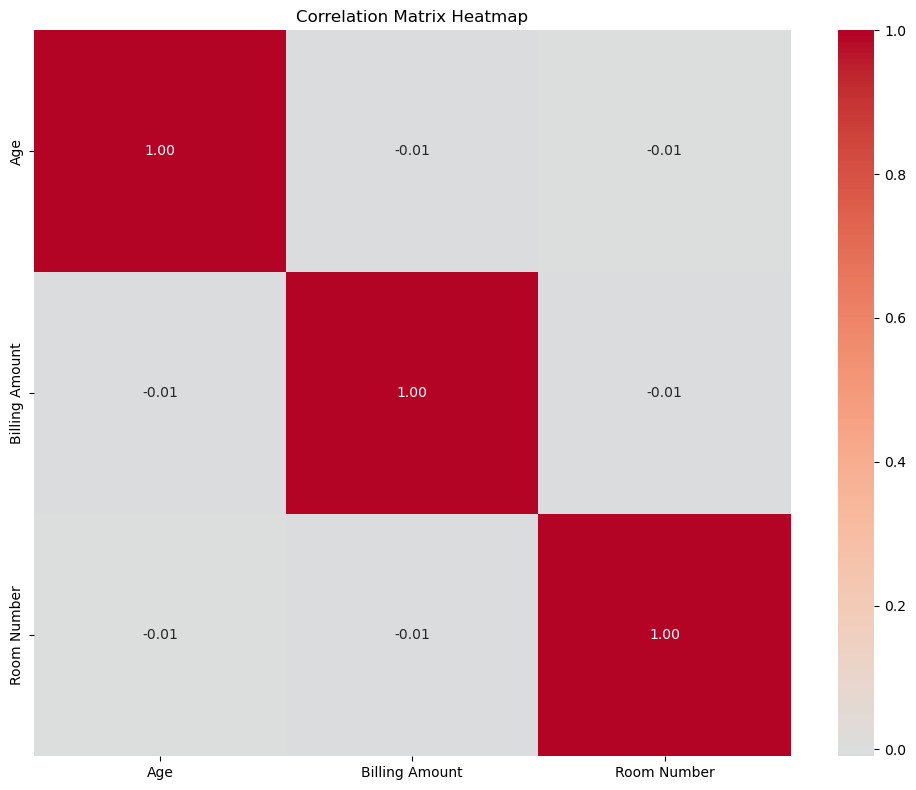


Correlation Matrix:
                     Age  Billing Amount  Room Number
Age             1.000000       -0.009483    -0.005371
Billing Amount -0.009483        1.000000    -0.006160
Room Number    -0.005371       -0.006160     1.000000


In [7]:
numeric_columns = med_info.select_dtypes(include=[np.number]).columns
correlation_matrix = med_info[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation_matrix)

**All correlation coefficients are extremely close to zero (|r| < 0.01)**
   
Age and Billing Amount: r = -0.009483 suggests that there is NO linear relationship
   
Age and Room Number: r = -0.005371 suggests that there is NO linear relationship
   
Billing Amount and Room Number: r =  -0.006160 suggests that there is NO linear relationship

**Remove features with more than 10 unique text values**

In [8]:
columns_to_check = med_info.select_dtypes(include=['object']).columns

for col in columns_to_check:
    unique_count = med_info[col].nunique()
    if unique_count > 10:
        print(f"Removing '{col}' - {unique_count} unique values (>10)")
        med_info = med_info.drop(columns=[col])
    else:
        print(f"Keeping '{col}' - {unique_count} unique values")

print(f"\nRemaining columns: {med_info.columns.tolist()}")

Removing 'Name' - 9378 unique values (>10)
Keeping 'Gender' - 2 unique values
Keeping 'Blood Type' - 8 unique values
Keeping 'Medical Condition' - 6 unique values
Removing 'Date of Admission' - 1815 unique values (>10)
Removing 'Doctor' - 9416 unique values (>10)
Removing 'Hospital' - 8639 unique values (>10)
Keeping 'Insurance Provider' - 5 unique values
Keeping 'Admission Type' - 3 unique values
Removing 'Discharge Date' - 1834 unique values (>10)
Keeping 'Medication' - 5 unique values
Keeping 'Test Results' - 3 unique values

Remaining columns: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Medication', 'Test Results']


**Remove insurance provider, billing amount, and room number**

In [9]:
columns_to_remove = ['Insurance Provider', 'Billing Amount', 'Room Number']
med_info = med_info.drop(columns=[col for col in columns_to_remove if col in med_info.columns])

print(f"Columns after removal: {med_info.columns.tolist()}")

Columns after removal: ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 'Medication', 'Test Results']


**Convert text values to numeric values**

In [10]:
df = med_info.copy()

# 1. Test Results
le = LabelEncoder()
df["Test Results"] = le.fit_transform(df["Test Results"])
print("Test Results classes:", le.classes_)
print("Mapping: Normal=0, Abnormal=1, Inconclusive=2")

# 2. Gender
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
print(df["Gender"].head())

# 3. Features with >2 unique values
categorical_cols = ["Blood Type", "Medical Condition", "Admission Type", "Medication"]
df = pd.get_dummies(df, columns=categorical_cols)
print(f"\n New shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Test Results classes: ['Abnormal' 'Inconclusive' 'Normal']
Mapping: Normal=0, Abnormal=1, Inconclusive=2
0    0
1    1
2    1
3    1
4    1
Name: Gender, dtype: int64

 New shape: (10000, 25)
Columns: ['Age', 'Gender', 'Test Results', 'Blood Type_A+', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-', 'Blood Type_B+', 'Blood Type_B-', 'Blood Type_O+', 'Blood Type_O-', 'Medical Condition_Arthritis', 'Medical Condition_Asthma', 'Medical Condition_Cancer', 'Medical Condition_Diabetes', 'Medical Condition_Hypertension', 'Medical Condition_Obesity', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medication_Aspirin', 'Medication_Ibuprofen', 'Medication_Lipitor', 'Medication_Paracetamol', 'Medication_Penicillin']


**Define X and y, create train/test split**

In [11]:
X = df.drop(columns=["Test Results"])
y = df["Test Results"]

In [12]:
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape (X): (10000, 24)
Target shape (y): (10000,)

Target distribution:
Test Results
0    3456
1    3277
2    3267
Name: count, dtype: int64


In [13]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDimensions:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


Dimensions:
X_train: (8000, 24)
y_train: (8000,)
X_test: (2000, 24)
y_test: (2000,)


In [14]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Train classifiers with k-fold cross-validation**

In [15]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(gamma="auto")
}


In [16]:
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=10, scoring="accuracy")
    f1 = cross_val_score(model, X_train, y_train, cv=10, scoring="f1_weighted")
    print(f"{name}: Accuracy = {acc.mean():.4f}, F1 = {f1.mean():.4f}")

Naive Bayes: Accuracy = 0.3337, F1 = 0.3331
Logistic Regression: Accuracy = 0.3321, F1 = 0.3245
SVM: Accuracy = 0.3312, F1 = 0.3254


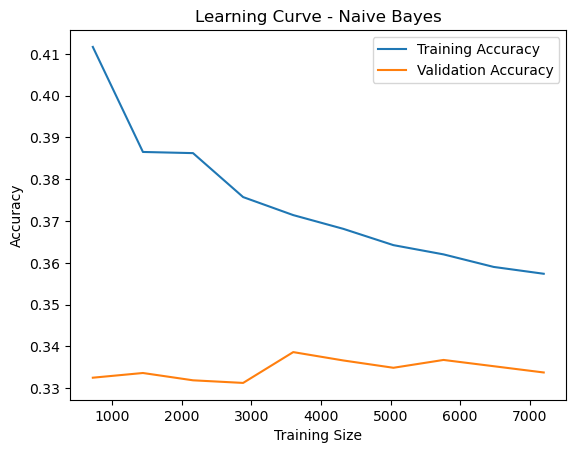

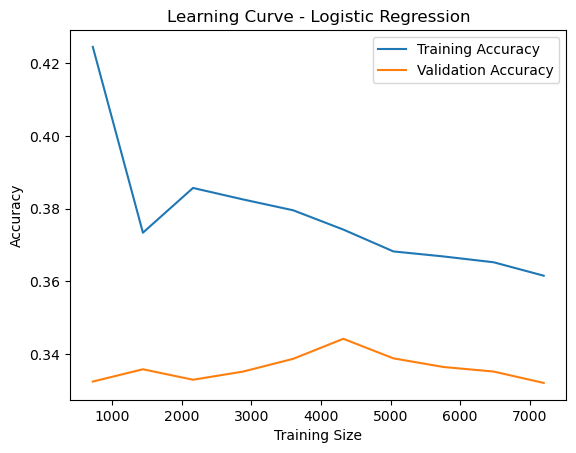

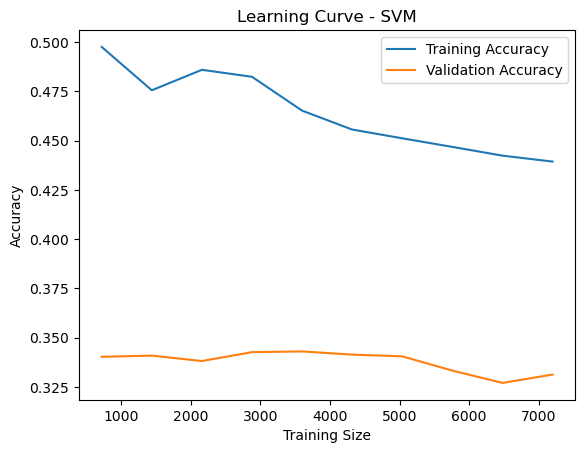

In [17]:
def plot_learning_curve(model, name, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=10, scoring="accuracy", 
        train_sizes=np.linspace(0.1, 1.0, 10))
    
    plt.figure()
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Accuracy")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Accuracy")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, name, X_train, y_train)

**Select best model and evaluate on test set**

In [18]:
best_model_name = None
best_f1 = -1

for name, model in models.items():
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=10, scoring="f1_weighted").mean()
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name

print(f"Best model based on highest F1 score: {best_model_name}")
print(f"Best CV F1 Score: {best_f1:.4f}")

Best model based on highest F1 score: SVM
Best CV F1 Score: 0.3376


In [19]:
if best_model_name == 'Naive Bayes':
    best_model = GaussianNB()
elif best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(random_state=42, max_iter=1000)
else:
    best_model = SVC(gamma='auto', random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)


**Test accuracy score, confusion matrix and classification report of the model**

In [20]:
test_accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"TEST SET EVALUATION - {best_model_name}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"\nClassification Report:")
print(class_report)

TEST SET EVALUATION - SVM
Test Accuracy: 0.3370

Confusion Matrix:
[[281 215 210]
 [263 183 190]
 [258 190 210]]

Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.35      0.40      0.37       706
Inconclusive       0.31      0.29      0.30       636
      Normal       0.34      0.32      0.33       658

    accuracy                           0.34      2000
   macro avg       0.34      0.33      0.33      2000
weighted avg       0.34      0.34      0.34      2000



**Examine metrics, scores, and learning curves**

All three models achieved an accuracy of around 33%, with the SVM performing slightly better than the others. The learning curves show a gap between training and validation accuracy; however, this more typically indicates overfitting, not underfitting, since the model performs better on training data than on validation data. This suggests the model is not generalising well to unseen data.

Overall, the data may be too noisy or lack informative features for the current models. Improving performance would likely require better-quality data, more relevant features, or exploring more advanced models that can capture complex patterns more effectively.

**RECOMMENDATIONS**

To improve performance, focus on collecting more data, addressing class imbalance, and applying feature engineering. Choose models based on macro F1 score, and consider advanced models such as Random Forest or Gradient Boosting. Finally, in deployment, monitor performance, handle uncertain predictions with confidence thresholds, and use ensemble methods for better reliability